# Preprocessing & Feature Engineering Roadmap
## 1. Feature Analysis and Feature Engineering
## 2. Data Preprocessing
## 3. Train-Test Split
## 4. Save Dataset for Training

In [1]:
# 1. Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os


# Text preprocessing
import re
from sklearn.model_selection import train_test_split

# Vectorization methods
from sklearn.feature_extraction.text import TfidfVectorizer
from sympy import false
from transformers import BertTokenizer, BertModel
import torch

# Feature analysis and selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr


# For saving processed data
import pickle
import joblib

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [2]:

# 2. Load the dataset
email_df = pd.read_csv('datasets/processed/cleaned_email_dataset.csv', low_memory=False)
email_df

,sender,subject,body,label,urls,source_dataset,urls_original
0,Young Esposito <Young@iworld.de>,Never agree to be a loser,Buck up your troubles caused by small dimension will soon be over! Become a lover no woman will be able to resist! http://whitedone.com/ come Even as Nazi tanks were rolling down the streets the dreamersphilosopher or a journalist He was still not sure I do the same,1,1,CEAS_08,True
1,Mok <iplines1983@icable.ph>,Befriend Jenna Jameson,Upgrade your sex and pleasures with these techniques http://www.brightmade.com,1,1,CEAS_08,True
2,Daily Top 10 <Karmandeep-opengevl@universalnet.psi.br>,CNN com Daily Top 10,THE DAILY TOP 10 from CNN.com Top videos and stories as of Aug 1 2008 3 58 PM EDT TOP 10 VIDEOS 1 MONTAUK MONSTER http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/07/31/moos.montauk.monster.cnn Is it a devil dog? Is it a turtle? Is it the Montauk Monster? CNN s Jeanne Moos asks what is this thing? 2 RACY PHOTOS OF TODDLER S MOM http://www.cnn.com/video/partners/email/index.html?url=/video/crime/2008/07/31/ng.racy.photos.cnn 3 NEWS OF THE ABSURD EPISODE 54 http://www.cnn.com/video/partners/email/index.html?url=/video/podcasts/absurd/site/2008/08/01/nota.episode.54.cnn 4 POLICE BEATING DISPUTE http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/07/31/levs.police.video.cnn 5 MOM PLEADS FOR GIRL S RETURN http://www.cnn.com/video/partners/email/index.html?url=/video/crime/2008/08/01/hill.boss.reigh.plea.cnn 6 DEFENDANT FAKES HEART ATTACK http://www.cnn.com/video/partners/email/index.html?url=/video/crime/2008/08/01/dnt.fake.heart.attack.mxf.whio 7 KILLER CARRIED VICTIM S HEAD http://www.cnn.com/video/partners/email/index.html?url=/video/world/2008/07/31/natpkg.can.bus.decapitation.ctv 8 MURDER CONFESSION RECANTED http://www.cnn.com/video/partners/email/index.html?url=/video/world/2008/08/01/blake.brazil.teen.murder.itn 9 ANTHRAX SUSPECT S HOME http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/08/01/von.dr.bruce.ivins.home.cnn 10 HECKLERS INTERRUPT OBAMA TALK http://www.cnn.com/video/partners/email/index.html?url=/video/politics/2008/08/01/sot.fl.obama.protesters.baynews9 TOP 10 STORIES 1 SUSPECT IN BEHEADING IDENTIFIED http://www.cnn.com/2008/WORLD/americas/08/01/canada.beheading/index.html Canadian police say Vince Weiguang Li 40 of Edmonton is charged with second degree murder in the beheading of a man on a bus 2 JUDGE TAKEN OFF LAST JENA 6 CASES http://www.cnn.com/2008/CRIME/08/01/jena6.appeal/index.html 3 PEOPLE MAG GETS PITT JOLIE PIX http://www.cnn.com/2008/SHOWBIZ/Movies/08/01/brangelina.photos.ap/index.html 4 ATTACK IN TORONTO CALLED RACIAL http://www.cnn.com/2008/WORLD/americas/08/01/canada.attack.ap/index.html 5 IREPORTERS UNUSUAL NAMES http://www.cnn.com/2008/LIVING/08/01/unusual.names.irpt/index.html 6 MOTHER PLEADS FOR CHILD S RETURN http://www.cnn.com/2008/CRIME/08/01/rockefeller.kidnapping/index.html 7 KARADZIC I MADE DEAL WITH U S http://www.cnn.com/2008/WORLD/europe/08/01/karadzic.trial/index.html 8 SUSPECT ARRESTED IN SWIM KILLINGS http://www.cnn.com/2008/CRIME/08/01/wisconsin.shooting.ap/index.html 9 ANTHRAX SUSPECT APPARENT SUICIDE http://www.cnn.com/2008/CRIME/08/01/anthrax.death/index.html 10 MCCAIN OBAMA CRITICISM FAIR http://www.cnn.com/2008/POLITICS/08/01/campaign.wrap/index.html CNN The Most Trusted Name in News Cable News Network LP LLLP One CNN Center Atlanta Georgia 30303 2008 Cable News Network LP LLLP A Time Warner Company,1,1,CEAS_08,True
3,Gretchen Suggs <externalsep1@loanofficertool.com>,SpecialPricesPharmMoreinfo,WelcomeFastShippingCustomerSupport http://7iwfna.blu.livefilestore.com/y1pXdX3kwzhBa8xhXv8tdHbjHn7Tj4VT91YQg5lB5-_Hs9yuDwmU5wOteqBO-KnULiisB2QJJIug_bNfnrNH0YoSw/index.html,1,1,CEAS_08,True
4,Caroline Aragon <dwthaidomainnamesm@thaidomainnames.com>,From Caroline Aragon,Yo wu urS mo ou go rc ebo eForM rgi oreWo iyv m ww en C mo L cfd IC eym K HE uys RE!!!,1,0,CEAS_08,True
...,...,...,...,...,...,...,...
99110,SC

In [3]:
# Drop unnecessary columns
email_df = email_df.drop(columns=['source_dataset', 'urls_original'])

print("Columns after dropping:")
print(email_df.columns.tolist())
print(f"\nDataset shape: {email_df.shape}")
print("\nRemaining columns:")
print(email_df.info())

Columns after dropping:
['sender', 'subject', 'body', 'label', 'urls']

Dataset shape: (99115, 5)

Remaining columns:
<class 'pandas.DataFrame'>
RangeIndex: 99115 entries, 0 to 99114
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   sender   99070 non-null  str  
 1   subject  97382 non-null  str  
 2   body     99095 non-null  str  
 3   label    99115 non-null  int64
 4   urls     99115 non-null  int64
dtypes: int64(2), str(3)
memory usage: 3.8 MB
None


## 1. Feature Analysis and Feature Engineering

In [4]:
import pandas as pd
import numpy as np
import re
import math

# SENDER/EMAIL PATTERN FEATURES (8 balanced features - NO lookup tables)
def extract_sender_components(sender):
    if pd.isna(sender) or sender.strip() == '':
        return pd.Series({'sender_name': None, 'sender_email': None, 'sender_domain': None})

    sender = sender.strip()
    pattern = r'(.+?)\s*<(.+?)>'
    match = re.search(pattern, sender)

    if match:
        sender_name = match.group(1).strip()
        sender_email = match.group(2).strip()
    else:
        sender_name = None
        sender_email = sender.strip()

    if sender_email:
        sender_email = sender_email.replace('<', '').replace('>', '').strip()

    if sender_email and '@' in sender_email:
        sender_domain = sender_email.split('@')[-1].strip()
    else:
        sender_domain = None

    return pd.Series({
        'sender_name': sender_name,
        'sender_email': sender_email,
        'sender_domain': sender_domain
    })

email_df[['sender_name', 'sender_email', 'sender_domain']] = email_df['sender'].apply(extract_sender_components)

def get_email_local_length(email):
    if pd.isna(email) or email.strip() == '':
        return 0
    if '@' in email:
        return len(email.split('@')[0])
    return 0

email_df['email_local_length'] = email_df['sender_email'].apply(get_email_local_length)

email_df['domain_length'] = email_df['sender_domain'].fillna('').str.len()

def get_email_digit_ratio(email):
    if pd.isna(email) or email.strip() == '':
        return 0
    local_part = email.split('@')[0] if '@' in email else email
    if len(local_part) == 0:
        return 0
    digit_count = sum(c.isdigit() for c in local_part)
    return digit_count / len(local_part)

email_df['email_digit_ratio'] = email_df['sender_email'].apply(get_email_digit_ratio)

def get_email_special_ratio(email):
    if pd.isna(email) or email.strip() == '':
        return 0
    local_part = email.split('@')[0] if '@' in email else email
    if len(local_part) == 0:
        return 0
    special_count = len(re.findall(r'[^a-zA-Z0-9]', local_part))
    return special_count / len(local_part)

email_df['email_special_char_ratio'] = email_df['sender_email'].apply(get_email_special_ratio)

def calculate_entropy(text):
    if not text or len(text) == 0:
        return 0
    freq = {}
    for char in text.lower():
        if char != ' ':
            freq[char] = freq.get(char, 0) + 1
    entropy = 0
    text_len = len([c for c in text if c != ' '])
    if text_len == 0:
        return 0
    for count in freq.values():
        probability = count / text_len
        entropy -= probability * math.log2(probability)
    return entropy

def get_domain_entropy(domain):
    if pd.isna(domain) or domain.strip() == '':
        return 0
    domain_parts = domain.split('.')
    if len(domain_parts) >= 2:
        main_domain = '.'.join(domain_parts[:-1])
    else:
        main_domain = domain
    return calculate_entropy(main_domain.lower())

email_df['domain_entropy'] = email_df['sender_domain'].apply(get_domain_entropy)

def get_vowel_consonant_ratio(domain):
    if pd.isna(domain) or domain.strip() == '':
        return 0
    domain_clean = re.sub(r'[^a-zA-Z]', '', domain.lower())
    if len(domain_clean) == 0:
        return 0
    vowels = sum(1 for char in domain_clean if char in 'aeiou')
    consonants = sum(1 for char in domain_clean if char in 'bcdfghjklmnpqrstvwxyz')
    if consonants == 0:
        return 0
    return vowels / consonants

email_df['domain_vowel_consonant_ratio'] = email_df['sender_domain'].apply(get_vowel_consonant_ratio)

email_df['sender_name_exists'] = email_df['sender_name'].notna().astype(int)

# v1_1 fix: shared-inbox whitelist. Legitimate automated senders
# (GitHub/noreply, Coursera/no-reply, Stripe/receipts, Airbnb/support, ...)
# have a display name that does not overlap with the mailbox local part;
# the local part is a generic role name rather than a personal identifier.
# Treat a match against this whitelist as consistent to avoid penalising
# role accounts for mismatching their display name.
SHARED_INBOX_LOCALS = frozenset({
    'noreply', 'donotreply', 'mailerdaemon', 'postmaster', 'newsletter',
    'digest', 'notifications', 'notification', 'receipts', 'support',
    'alerts', 'hello', 'contact', 'info', 'team', 'help', 'news', 'updates',
    'billing', 'admin',
})

def check_name_email_consistency(row):
    name = row['sender_name']
    email = row['sender_email']

    if pd.isna(name) or pd.isna(email):
        return 0

    name_clean = re.sub(r'[^a-zA-Z]', '', name.lower())
    email_local = email.split('@')[0] if '@' in email else email
    email_clean = re.sub(r'[^a-zA-Z]', '', email_local.lower())

    if len(name_clean) == 0 or len(email_clean) == 0:
        return 0

    # Shared-inbox local parts are role accounts; the display-name mismatch
    # carries no phishing signal.
    if email_clean in SHARED_INBOX_LOCALS:
        return 1

    name_parts = name_clean.split()
    for part in name_parts:
        if len(part) > 2 and part in email_clean:
            return 1

    if len(name_clean) >= 3:
        for i in range(len(name_clean) - 2):
            substring = name_clean[i:i+3]
            if substring in email_clean:
                return 1

    return 0

email_df['name_email_consistency'] = email_df.apply(check_name_email_consistency, axis=1)

print(f"Created 8 sender pattern features")

# =============================================================================
# SUBJECT FEATURES (6 features)
# =============================================================================

email_df['subject'] = email_df['subject'].fillna('')

email_df['subject_length'] = email_df['subject'].str.len()
email_df['subject_word_count'] = email_df['subject'].str.split().str.len().fillna(0).astype(int)
email_df['subject_exclamation_count'] = email_df['subject'].str.count('!')
email_df['subject_question_count'] = email_df['subject'].str.count(r'\?')

def get_special_char_ratio(text):
    if pd.isna(text) or len(text) == 0:
        return 0
    special_chars = re.findall(r'[^a-zA-Z0-9\s]', text)
    return len(special_chars) / len(text)

email_df['subject_special_char_ratio'] = email_df['subject'].apply(get_special_char_ratio)
email_df['subject_entropy'] = email_df['subject'].apply(calculate_entropy)

print(f"Created 6 subject features")

# =============================================================================
# BODY FEATURES (8 features)
# =============================================================================

email_df['body'] = email_df['body'].fillna('')

email_df['body_length'] = email_df['body'].str.len()
email_df['body_word_count'] = email_df['body'].str.split().str.len().fillna(0).astype(int)

# url_patterns = [
#     r'https?://[^\s<>\"\'\)]+',
#     r'ftp://[^\s<>\"\'\)]+',
#     r'www\.[^\s<>\"\'\)]+',
#     r'mailto:[^\s<>\"\'\)]+',
# ]

url_patterns = [
    r'https?://[^\s<>\"\'\)]+',           # http:// or https://
    r'ftp://[^\s<>\"\'\)]+',              # ftp://
    r'ftps://[^\s<>\"\'\)]+',             # ftps://
    r'sftp://[^\s<>\"\'\)]+',             # sftp://
    r'www\.[^\s<>\"\'\)]+',               # www.
    r'file://[^\s<>\"\'\)]+',             # file://
    r'ssh://[^\s<>\"\'\)]+',              # ssh://
    r'telnet://[^\s<>\"\'\)]+',           # telnet://
    r'git://[^\s<>\"\'\)]+',              # git://
    r'svn://[^\s<>\"\'\)]+',              # svn://
    r'mailto:[^\s<>\"\'\)]+',             # mailto:
    r'news:[^\s<>\"\'\)]+',               # news:
    r'nntp://[^\s<>\"\'\)]+',             # nntp://
    r'irc://[^\s<>\"\'\)]+',              # irc://
    r'webcal://[^\s<>\"\'\)]+',           # webcal://
]

def count_urls(text):
    if pd.isna(text) or text.strip() == '':
        return 0
    total_urls = 0
    for pattern in url_patterns:
        urls = re.findall(pattern, text)
        total_urls += len(urls)
    return total_urls

email_df['body_url_count'] = email_df['body'].apply(count_urls)

def get_url_density(row):
    if row['body_word_count'] == 0:
        return 0
    return (row['body_url_count'] / row['body_word_count']) * 100

email_df['body_url_density'] = email_df.apply(get_url_density, axis=1)

email_df['body_exclamation_count'] = email_df['body'].str.count('!')
email_df['body_question_count'] = email_df['body'].str.count(r'\?')

def get_avg_word_length(text):
    if pd.isna(text) or text.strip() == '':
        return 0
    words = text.split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

email_df['body_avg_word_length'] = email_df['body'].apply(get_avg_word_length)
email_df['body_entropy'] = email_df['body'].apply(calculate_entropy)

print(f"Created 8 body features")

# =============================================================================
# FINAL FEATURE LIST (22 total - NO LOOKUP TABLES)
# =============================================================================

SELECTED_FEATURES = [
    # Sender pattern features (8)
    'email_local_length',
    'domain_length',
    'email_digit_ratio',
    'email_special_char_ratio',
    'domain_entropy',
    'domain_vowel_consonant_ratio',
    'sender_name_exists',
    'name_email_consistency',

    # Subject features (6)
    'subject_length',
    'subject_word_count',
    'subject_exclamation_count',
    'subject_question_count',
    'subject_special_char_ratio',
    'subject_entropy',

    # Body features (8)
    'body_length',
    'body_word_count',
    'body_url_count',
    'body_url_density',
    'body_exclamation_count',
    'body_question_count',
    'body_avg_word_length',
    'body_entropy'
]


print(f"Total engineered features: {len(SELECTED_FEATURES)}")

for i, feat in enumerate(SELECTED_FEATURES, 1):
    category = "Sender" if i <= 8 else "Subject" if i <= 14 else "Body"
    print(f"  {i:2d}. [{category:7s}] {feat}")

Created 8 sender pattern features
Created 6 subject features
Created 8 body features
Total engineered features: 22
   1. [Sender ] email_local_length
   2. [Sender ] domain_length
   3. [Sender ] email_digit_ratio
   4. [Sender ] email_special_char_ratio
   5. [Sender ] domain_entropy
   6. [Sender ] domain_vowel_consonant_ratio
   7. [Sender ] sender_name_exists
   8. [Sender ] name_email_consistency
   9. [Subject] subject_length
  10. [Subject] subject_word_count
  11. [Subject] subject_exclamation_count
  12. [Subject] subject_question_count
  13. [Subject] subject_special_char_ratio
  14. [Subject] subject_entropy
  15. [Body   ] body_length
  16. [Body   ] body_word_count
  17. [Body   ] body_url_count
  18. [Body   ] body_url_density
  19. [Body   ] body_exclamation_count
  20. [Body   ] body_question_count
  21. [Body   ] body_avg_word_length
  22. [Body   ] body_entropy


In [5]:
email_df.head(20)

,sender,subject,body,label,urls,sender_name,sender_email,sender_domain,email_local_length,domain_length,email_digit_ratio,email_special_char_ratio,domain_entropy,domain_vowel_consonant_ratio,sender_name_exists,name_email_consistency,subject_length,subject_word_count,subject_exclamation_count,subject_question_count,subject_special_char_ratio,subject_entropy,body_length,body_word_count,body_url_count,body_url_density,body_exclamation_count,body_question_count,body_avg_word_length,body_entropy
0,Young Esposito <Young@iworld.de>,Never agree to be a loser,Buck up your troubles caused by small dimension will soon be over! Become a lover no woman will be able to resist! http://whitedone.com/ come Even as Nazi tanks were rolling down the streets the dreamersphilosopher or a journalist He was still not sure I do the same,1,1,Young Esposito,Young@iworld.de,iworld.de,5,9,0.000000,0.000000,2.584963,0.600000,1,1,25,6,0,0,0.0,3.108695,266,47,1,2.127660,2,0,4.680851,4.229669
1,Mok <iplines1983@icable.ph>,Befriend Jenna Jameson,Upgrade your sex and pleasures with these techniques http://www.brightmade.com,1,1,Mok,iplines1983@icable.ph,icable.ph,11,9,0.363636,0.000000,2.584963,0.600000,1,0,22,3,0,0,0.0,3.321928,78,9,2,22.222222,0,0,7.777778,4.307525
2,Daily Top 10 <Karmandeep-opengevl@universalnet.psi.br>,CNN com Daily Top 10,THE DAILY TOP 10 from CNN.com Top videos and stories as of Aug 1 2008 3 58 PM EDT TOP 10 VIDEOS 1 MONTAUK MONSTER http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/07/31/moos.montauk.monster.cnn Is it a devil dog? Is it a turtle? Is it the Montauk Monster? CNN s Jeanne Moos asks what is this thing? 2 RACY PHOTOS OF TODDLER S MOM http://www.cnn.com/video/partners/email/index.html?url=/video/crime/2008/07/31/ng.racy.photos.cnn 3 NEWS OF THE ABSURD EPISODE 54 http://www.cnn.com/video/partners/email/index.html?url=/video/podcasts/absurd/site/2008/08/01/nota.episode.54.cnn 4 POLICE BEATING DISPUTE http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/07/31/levs.police.video.cnn 5 MOM PLEADS FOR GIRL S RETURN http://www.cnn.com/video/partners/email/index.html?url=/video/crime/2008/08/01/hill.boss.reigh.plea.cnn 6 DEFENDANT FAKES HEART ATTACK http://www.cnn.com/video/partners/email/index.html?url=/video/crime/2008/08/01/dnt.fake.heart.attack.mxf.whio 7 KILLER CARRIED VICTIM S HEAD http://www.cnn.com/video/partners/email/index.html?url=/video/world/2008/07/31/natpkg.can.bus.decapitation.ctv 8 MURDER CONFESSION RECANTED http://www.cnn.com/video/partners/email/index.html?url=/video/world/2008/08/01/blake.brazil.teen.murder.itn 9 ANTHRAX SUSPECT S HOME http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/08/01/von.dr.bruce.ivins.home.cnn 10 HECKLERS INTERRUPT OBAMA TALK http://www.cnn.com/video/partners/email/index.html?url=/video/politics/2008/08/01/sot.fl.obama.protesters.baynews9 TOP 10 STORIES 1 SUSPECT IN BEHEADING IDENTIFIED http://www.cnn.com/2008/WORLD/americas/08/01/canada.beheading/index.html Canadian police say Vince Weiguang Li 40 of Edmonton is charged with second degree murder in the beheading of a man on a bus 2 JUDGE TAKEN OFF LAST JENA 6 CASES http://www.cnn.com/2008/CRIME/08/01/jena6.appeal/index.html 3 PEOPLE MAG GETS PITT JOLIE PIX http://www.cnn.com/2008/SHOWBIZ/Movies/08/01/brangelina.photos.ap/index.html 4 ATTACK IN TORONTO CALLED RACIAL http://www.cnn.com/2008/WORLD/americas/08/01/canada.attack.ap/index.html 5 IREPORTERS UNUSUAL NAMES http://www.cnn.com/2008/LIVING/08/01/unusual.names.irpt/index.html 6 MOTHER PLEADS FOR CHILD S RETURN http://www.cnn.com/2008/CRIME/08/01/rockefeller.kidnapping/index.html 7 KARADZIC I MADE DEAL WITH U S http://www.cnn.com/2008/WORLD/europe/08/01/karadzic.trial/index.html 8 SUSPECT ARRESTED IN SWIM KILLINGS http://www.cnn.com/2008/CRIME/08/01/wisconsin.shooting.ap/index.html 9 ANTHRAX SUSPECT APPARENT SUICIDE http://www.cnn.com/2008/CRIME/08/01/anthrax.death/index.html 10 MCCAIN OBAMA CRITICISM FAIR http://www.cnn.com/2008/POL

### DROP UNNECESSARY COLUMNS

In [6]:
print(f"\nDataset shape BEFORE dropping: {email_df.shape}")
print(f"Columns BEFORE: {email_df.columns.tolist()}\n")

# Columns to drop with reasons
columns_to_drop = [
    'sender',           # Raw sender text (acts as unique identifier, causes model to memorize
                        # specific senders instead of learning patterns, creates data leakage
                        # and bias - legitimate senders would always be classified as legitimate)

    'sender_name',      # Extracted sender name (also acts as identifier, model could memorize
                        # specific names like "John Smith" instead of learning structural patterns,
                        # poor generalization to new/unseen names)

    'sender_email',     # Extracted sender email (unique identifier per sender, causes memorization,
                        # model won't generalize to new phishing emails from different addresses,
                        # all useful patterns already captured in engineered features)

    'sender_domain',    # Raw domain text (acts as identifier with 62k+ unique values, causes
                        # memorization of specific domains, replaced by engineered features:
                        # domain_frequency, domain_entropy, domain_length, is_rare_domain, etc.
                        # which capture domain patterns without memorizing specific domains)
]

# Drop columns
email_df = email_df.drop(columns=columns_to_drop)

print(f"\nDataset shape AFTER dropping: {email_df.shape}")
print(f"\nColumns AFTER: {email_df.columns.tolist()}")

# Display remaining column categories
print("\n" + "="*80)
print("REMAINING COLUMNS BY CATEGORY")
print("="*80)

# Original columns
original_cols = ['subject', 'body', 'label', 'urls']
print(f"\nOriginal Columns ({len([c for c in original_cols if c in email_df.columns])}):")
print([c for c in original_cols if c in email_df.columns])

# Sender/Domain engineered features
sender_features = [col for col in email_df.columns if col.startswith(('sender_', 'email_', 'domain_', 'is_rare', 'tld_'))]
print(f"\nSender/Domain Engineered Features ({len(sender_features)}):")
print(sender_features)

# Subject engineered features
subject_features = [col for col in email_df.columns if col.startswith('subject_')]
print(f"\nSubject Engineered Features ({len(subject_features)}):")
print(subject_features)

# Body engineered features
body_features = [col for col in email_df.columns if col.startswith('body_')]
print(f"\nBody Engineered Features ({len(body_features)}):")
print(body_features)

print("\n" + "="*80)
print(f"TOTAL COLUMNS: {len(email_df.columns)}")
print(f"TOTAL ENGINEERED FEATURES: {len(sender_features) + len(subject_features) + len(body_features)}")
print("="*80)


Dataset shape BEFORE dropping: (99115, 30)
Columns BEFORE: ['sender', 'subject', 'body', 'label', 'urls', 'sender_name', 'sender_email', 'sender_domain', 'email_local_length', 'domain_length', 'email_digit_ratio', 'email_special_char_ratio', 'domain_entropy', 'domain_vowel_consonant_ratio', 'sender_name_exists', 'name_email_consistency', 'subject_length', 'subject_word_count', 'subject_exclamation_count', 'subject_question_count', 'subject_special_char_ratio', 'subject_entropy', 'body_length', 'body_word_count', 'body_url_count', 'body_url_density', 'body_exclamation_count', 'body_question_count', 'body_avg_word_length', 'body_entropy']


Dataset shape AFTER dropping: (99115, 26)

Columns AFTER: ['subject', 'body', 'label', 'urls', 'email_local_length', 'domain_length', 'email_digit_ratio', 'email_special_char_ratio', 'domain_entropy', 'domain_vowel_consonant_ratio', 'sender_name_exists', 'name_email_consistency', 'subject_length', 'subject_word_count', 'subject_exclamation_count', 's

## 2. Data Preprocessing

### TEXT CLEANING (After Feature Extraction, Before Vectorization)
#### Final Text Normalization Strategy:
After all features are extracted, we normalize text for TF-IDF vectorization:
1. Remove URLs (features already captured: body_url_count, body_url_density)
2. Remove ! and ? (features already captured: exclamation/question counts)
3. Convert to lowercase (features already captured: uppercase ratios, case patterns)
4. Normalize whitespace (remove excessive spaces, newlines)

This ensures TF-IDF focuses on WORD SEMANTICS, not formatting artifacts.


In [7]:
def normalize_text_for_tfidf(text, url_patterns):
    """
    Normalize text for TF-IDF vectorization.

    Removes:
    - URLs (all formats)
    - Exclamation marks (!)
    - Question marks (?)
    - Excessive whitespace

    Applies:
    - Lowercase conversion
    - Whitespace normalization

    Args:
        text (str): Raw text to normalize
        url_patterns (list): List of regex patterns for URL detection

    Returns:
        str: Normalized text ready for TF-IDF
    """
    if pd.isna(text) or text.strip() == '':
        return ''

    # Combine all URL patterns
    combined_url_pattern = '|'.join(url_patterns)

    # Step 1: Remove URLs
    text = re.sub(combined_url_pattern, '', text)

    # Step 2: Remove ! and ?
    text = re.sub(r'[!?]+', '', text)

    # Step 3: Convert to lowercase
    text = text.lower()

    # Step 4: Normalize whitespace
    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)

    # Strip leading/trailing whitespace
    text = text.strip()

    return text


In [8]:
combined_url_pattern = '|'.join(url_patterns)

# Count before normalization
subject_urls_before = email_df['subject'].str.contains(combined_url_pattern, regex=True).sum()
body_urls_before = email_df['body'].str.contains(combined_url_pattern, regex=True).sum()

subject_punct_before = email_df['subject'].str.contains(r'[!?]', regex=True).sum()
body_punct_before = email_df['body'].str.contains(r'[!?]', regex=True).sum()

subject_has_uppercase = email_df['subject'].apply(lambda x: any(c.isupper() for c in str(x))).sum()
body_has_uppercase = email_df['body'].apply(lambda x: any(c.isupper() for c in str(x))).sum()

print("\nBEFORE NORMALIZATION:")
print(f"  URLs - Subject: {subject_urls_before:,} | Body: {body_urls_before:,}")
print(f"  ! or ? - Subject: {subject_punct_before:,} | Body: {body_punct_before:,}")
print(f"  Uppercase - Subject: {subject_has_uppercase:,} | Body: {body_has_uppercase:,}")

# Apply normalization
print("\nNormalizing subject column...")
email_df['subject'] = email_df['subject'].apply(lambda x: normalize_text_for_tfidf(x, url_patterns))

print("Normalizing body column...")
email_df['body'] = email_df['body'].apply(lambda x: normalize_text_for_tfidf(x, url_patterns))

# Count after normalization
subject_urls_after = email_df['subject'].str.contains(combined_url_pattern, regex=True).sum()
body_urls_after = email_df['body'].str.contains(combined_url_pattern, regex=True).sum()

subject_punct_after = email_df['subject'].str.contains(r'[!?]', regex=True).sum()
body_punct_after = email_df['body'].str.contains(r'[!?]', regex=True).sum()

subject_has_uppercase_after = email_df['subject'].apply(lambda x: any(c.isupper() for c in str(x))).sum()
body_has_uppercase_after = email_df['body'].apply(lambda x: any(c.isupper() for c in str(x))).sum()

# Show sample normalized text
print("\nSample Normalized Text (first 3 emails):")
for i in range(min(3, len(email_df))):
    print(f"\n--- Email {i+1} ---")
    print(f"Subject: {email_df.iloc[i]['subject'][:100]}...")
    print(f"Body: {email_df.iloc[i]['body'][:200]}...")


BEFORE NORMALIZATION:
  URLs - Subject: 0 | Body: 57,502
  ! or ? - Subject: 13,270 | Body: 63,403
  Uppercase - Subject: 83,883 | Body: 97,572

Normalizing subject column...
Normalizing body column...

Sample Normalized Text (first 3 emails):

--- Email 1 ---
Subject: never agree to be a loser...
Body: buck up your troubles caused by small dimension will soon be over become a lover no woman will be able to resist come even as nazi tanks were rolling down the streets the dreamersphilosopher or a jour...

--- Email 2 ---
Subject: befriend jenna jameson...
Body: upgrade your sex and pleasures with these techniques...

--- Email 3 ---
Subject: cnn com daily top 10...
Body: the daily top 10 from cnn.com top videos and stories as of aug 1 2008 3 58 pm edt top 10 videos 1 montauk monster is it a devil dog is it a turtle is it the montauk monster cnn s jeanne moos asks what...


In [9]:
email_df.head(20)

,subject,body,label,urls,email_local_length,domain_length,email_digit_ratio,email_special_char_ratio,domain_entropy,domain_vowel_consonant_ratio,sender_name_exists,name_email_consistency,subject_length,subject_word_count,subject_exclamation_count,subject_question_count,subject_special_char_ratio,subject_entropy,body_length,body_word_count,body_url_count,body_url_density,body_exclamation_count,body_question_count,body_avg_word_length,body_entropy
0,never agree to be a loser,buck up your troubles caused by small dimension will soon be over become a lover no woman will be able to resist come even as nazi tanks were rolling down the streets the dreamersphilosopher or a journalist he was still not sure i do the same,1,1,5,9,0.000000,0.000000,2.584963,0.600000,1,1,25,6,0,0,0.0,3.108695,266,47,1,2.127660,2,0,4.680851,4.229669
1,befriend jenna jameson,upgrade your sex and pleasures with these techniques,1,1,11,9,0.363636,0.000000,2.584963,0.600000,1,0,22,3,0,0,0.0,3.321928,78,9,2,22.222222,0,0,7.777778,4.307525
2,cnn com daily top 10,the daily top 10 from cnn.com top videos and stories as of aug 1 2008 3 58 pm edt top 10 videos 1 montauk monster is it a devil dog is it a turtle is it the montauk monster cnn s jeanne moos asks what is this thing 2 racy photos of toddler s mom 3 news of the absurd episode 54 4 police beating dispute 5 mom pleads for girl s return 6 defendant fakes heart attack 7 killer carried victim s head 8 murder confession recanted 9 anthrax suspect s home 10 hecklers interrupt obama talk top 10 stories 1 suspect in beheading identified canadian police say vince weiguang li 40 of edmonton is charged with second degree murder in the beheading of a man on a bus 2 judge taken off last jena 6 cases 3 people mag gets pitt jolie pix 4 attack in toronto called racial 5 ireporters unusual names 6 mother pleads for child s return 7 karadzic i made deal with u s 8 suspect arrested in swim killings 9 anthrax suspect apparent suicide 10 mccain obama criticism fair cnn the most trusted name in news cable news network lp lllp one cnn center atlanta georgia 30303 2008 cable news network lp lllp a time warner company,1,1,19,19,0.000000,0.052632,3.500000,0.545455,1,0,20,5,0,0,0.0,3.625000,2857,234,40,17.094017,0,14,11.213675,4.689871
3,specialpricespharmmoreinfo,welcomefastshippingcustomersupport,1,1,12,19,0.083333,0.000000,3.106891,0.800000,1,0,26,1,0,0,0.0,3.584303,171,2,1,50.000000,0,0,85.000000,5.039773
4,from caroline aragon,yo wu urs mo ou go rc ebo eform rgi orewo iyv m ww en c mo l cfd ic eym k he uys re,1,0,18,19,0.000000,0.000000,3.189898,0.800000,1,0,20,3,0,0,0.0,3.266333,86,25,0,0.000000,3,0,2.480000,3.973390
5,replica watches,we have fake swiss men s and ladie s replica watches from rolex to the popular panerai watch more information here,1,0,7,21,0.000000,0.000000,3.690117,0.666667,1,0,15,2,0,0,0.0,3.378783,114,21,0,0.000000,0,0,4.476190,4.010236
6,cnn com daily top 10,the daily top 10 from cnn.com top videos and stories as of aug 1 2008 3 58 pm edt top 10 videos 1 montauk monster is it a devil dog is it a turtle is it the montauk monster cnn s jeanne moos asks what is this thing 2 racy photos of toddler s mom 3 news of the absurd episode 54 4 police beating dispute 5 mom pleads for girl s return 6 defendant fakes heart attack 7 killer carried victim s head 8 murder confession recanted 9 anthrax suspect s home 10 hecklers interrupt obama talk top 10 stories 1 suspect in beheading identified canadian police say vince weiguang li 40 of edmonton is charged with second degree murder in the beheading of a man on a bus 2 judge taken off last jena 6 cases 3 people mag gets pitt jolie pix 4 attack in toronto called racial 5 ireporters unusual names 6 mother pleads for child s return 7 karadzic i made deal with u s 8 suspect arrested in swim killings 9 anthrax suspect apparent suicide 10 mccain obama criticism fair cnn the most trusted name in news cable news network lp lllp one cnn center atlanta georgia 30303 2008 cable news 

In [10]:
email_df.isnull().sum()

subject                         0
body                            0
label                           0
urls                            0
email_local_length              0
domain_length                   0
email_digit_ratio               0
email_special_char_ratio        0
domain_entropy                  0
domain_vowel_consonant_ratio    0
sender_name_exists              0
name_email_consistency          0
subject_length                  0
subject_word_count              0
subject_exclamation_count       0
subject_question_count          0
subject_special_char_ratio      0
subject_entropy                 0
body_length                     0
body_word_count                 0
body_url_count                  0
body_url_density                0
body_exclamation_count          0
body_question_count             0
body_avg_word_length            0
body_entropy                    0
dtype: int64

#### CHECK AND REMOVE ALL NaN VALUES FROM DATASET

In [11]:
print(f"\nDataset shape BEFORE removing NaNs: {email_df.shape}")

# Check for NaN values in all columns
print("\n1. NaN COUNT PER COLUMN:")
print("-"*80)
nan_summary = email_df.isnull().sum()
print(nan_summary)

total_nans = nan_summary.sum()
print(f"\nTotal NaN values across all columns: {total_nans}")

# Identify columns with NaN values
columns_with_nan = nan_summary[nan_summary > 0].index.tolist()
print(f"\nColumns with NaN values: {columns_with_nan}")

# Show percentage of NaN per column
if len(columns_with_nan) > 0:
    print("\n2. NaN PERCENTAGE PER COLUMN:")
    print("-"*80)
    for col in columns_with_nan:
        nan_pct = (email_df[col].isnull().sum() / len(email_df)) * 100
        print(f"   {col}: {email_df[col].isnull().sum()} NaNs ({nan_pct:.2f}%)")

# Count rows with ANY NaN value
rows_with_nan = email_df.isnull().any(axis=1).sum()
print(f"\n3. ROWS WITH ANY NaN VALUE:")
print("-"*80)
print(f"Total rows with NaN: {rows_with_nan}")
print(f"Percentage: {(rows_with_nan / len(email_df)) * 100:.2f}%")

# Show sample of rows with NaN
if rows_with_nan > 0:
    print("\n4. SAMPLE ROWS WITH NaN VALUES:")
    print("-"*80)
    nan_rows = email_df[email_df.isnull().any(axis=1)]
    print(nan_rows.head(10))

    # Check label distribution
    print("\n5. LABEL DISTRIBUTION OF ROWS WITH NaN:")
    print("-"*80)
    print(nan_rows['label'].value_counts())
    print(f"Phishing: {(nan_rows['label'] == 1).sum()}")
    print(f"Legitimate: {(nan_rows['label'] == 0).sum()}")

# Drop all rows with ANY NaN values
print("\n6. DROPPING ROWS WITH NaN VALUES...")
print("-"*80)
email_df_clean = email_df.dropna()

print(f"Rows dropped: {len(email_df) - len(email_df_clean)}")
print(f"Dataset shape AFTER removing NaNs: {email_df_clean.shape}")

# Update the main dataframe
email_df = email_df_clean.copy()

# Verify no NaN values remain
print("\n7.VERIFICATION - NaN COUNT AFTER CLEANING:")
print("-"*80)
remaining_nans = email_df.isnull().sum().sum()
print(f"Total remaining NaN values: {remaining_nans}")



Dataset shape BEFORE removing NaNs: (99115, 26)

1. NaN COUNT PER COLUMN:
--------------------------------------------------------------------------------
subject                         0
body                            0
label                           0
urls                            0
email_local_length              0
domain_length                   0
email_digit_ratio               0
email_special_char_ratio        0
domain_entropy                  0
domain_vowel_consonant_ratio    0
sender_name_exists              0
name_email_consistency          0
subject_length                  0
subject_word_count              0
subject_exclamation_count       0
subject_question_count          0
subject_special_char_ratio      0
subject_entropy                 0
body_length                     0
body_word_count                 0
body_url_count                  0
body_url_density                0
body_exclamation_count          0
body_question_count             0
body_avg_word_length        

#### SUBJECT VECTORIZATION (Unigrams Only)

In [12]:
# Initialize Subject TF-IDF Vectorizer
# v1_1 fix: stop_words='english' removes generic pronouns/articles that inherited
# a phishing lean from the 2007-2008 corpus base rate (your/you/our/here/from).
# min_df=1 lets rare but informative modern tokens (github, noreply, unsubscribe)
# enter the vocabulary. max_features stays at 2000 so the input dimension is
# unchanged.
subject_vectorizer = TfidfVectorizer(
    max_features=2000,      # Keep top 2000 features (subjects are short)
    ngram_range=(1, 1),     # Unigrams only (single words)
    min_df=1,               # Accept single-document terms (modern vocab coverage)
    max_df=0.95,            # Ignore terms appearing in more than 95% of documents (too common)
    sublinear_tf=True,      # Use log scaling for term frequency (reduces impact of very frequent terms)
    stop_words='english'    # Drop stopwords so generic tokens carry no phishing lean
)

# Fit and transform subject text
subject_tfidf = subject_vectorizer.fit_transform(email_df['subject'])

print(f"Shape: {subject_tfidf.shape}")
print(f"Features: {subject_tfidf.shape[1]} TF-IDF features (unigrams)")
print(f"Sparsity: {(1 - subject_tfidf.nnz / (subject_tfidf.shape[0] * subject_tfidf.shape[1])) * 100:.2f}%")

# Sample feature names
print()
print("Sample features (first 20):")
print(f"{subject_vectorizer.get_feature_names_out()[:20]}")

# Convert subject TF-IDF to DataFrame
subject_tfidf_df = pd.DataFrame(
    subject_tfidf.toarray(),
    columns=[f'subject_tfidf_{i}' for i in range(subject_tfidf.shape[1])],
    index=email_df.index  # Preserve original index
)

print(f"Subject TF-IDF DataFrame created: {subject_tfidf_df.shape}")

# Combine with email_df (drop original subject column)
email_df = email_df.drop(columns=['subject'])
email_df = pd.concat([email_df, subject_tfidf_df], axis=1)

print(f"Subject column replaced with TF-IDF features!")
print(f"Updated email_df shape: {email_df.shape}")


Shape: (99115, 2000)
Features: 2000 TF-IDF features (unigrams)
Sparsity: 99.86%

Sample features (first 20):
['00' '000' '01' '02' '03' '04' '05' '0500' '06' '07' '0700' '08' '0800'
 '09' '0em' '0ffers' '0nline' '0rder' '0ver' '10']
Subject TF-IDF DataFrame created: (99115, 2000)
Subject column replaced with TF-IDF features!
Updated email_df shape: (99115, 2025)


#### BODY VECTORIZATION (Unigrams + Bigrams)

##### Initialize Body TF-IDF Vectorizer

##### We use BOTH unigrams and bigrams for body because:

1. Phishing emails use specific PHRASES that indicate malicious intent:
    - "click here", "verify account", "limited time", "act now", "suspended account"
2. Single words (unigrams) alone miss context:
    - "verify" vs "verify account" - the phrase is more suspicious
    - "click" vs "click here" - the phrase is a stronger phishing signal
3. Body text is long enough (~1000 chars avg) to have meaningful bigrams
4. Bigrams capture common phishing patterns that appear as consecutive words
5. The combination gives the model both individual keywords AND contextual phrases

In [13]:
# v1_1 fix: stop_words='english' + min_df=1 -> same rationale as subject vectoriser (cell 18).
# max_features stays at 5000 so the body TF-IDF block remains 5000 columns.
body_vectorizer = TfidfVectorizer(
    max_features=5000,      # Keep top 5000 features (body is longer, needs more features)
    ngram_range=(1, 2),     # Both unigrams (1) and bigrams (2) - captures phrases!
    min_df=1,               # Accept single-document terms (modern vocab coverage)
    max_df=0.95,            # Ignore terms appearing in more than 95% of documents
    sublinear_tf=True,      # Use log scaling for term frequency
    stop_words='english'    # Drop stopwords so generic tokens carry no phishing lean
)

# Fit and transform body text
body_tfidf = body_vectorizer.fit_transform(email_df['body'])

print(f"Shape: {body_tfidf.shape}")
print(f"Features: {body_tfidf.shape[1]} TF-IDF features (unigrams + bigrams)")
print(f"Sparsity: {(1 - body_tfidf.nnz / (body_tfidf.shape[0] * body_tfidf.shape[1])) * 100:.2f}%")

# Sample feature names
print()
print("Sample features (first 20):")
sample_features = body_vectorizer.get_feature_names_out()[:20]
print(f"{sample_features}")

# Analyze unigrams vs bigrams
all_features = body_vectorizer.get_feature_names_out()
unigrams = [f for f in all_features if ' ' not in f]
bigrams = [f for f in all_features if ' ' in f]

print()
print(f"Unigrams count: {len(unigrams)}")
print(f"Bigrams count: {len(bigrams)}")
print()
print(f"Sample unigrams (first 10): {unigrams[:10]}")
print(f"Sample bigrams (first 10): {bigrams[:10]}")

# Convert body TF-IDF to DataFrame
body_tfidf_df = pd.DataFrame(
    body_tfidf.toarray(),
    columns=[f'body_tfidf_{i}' for i in range(body_tfidf.shape[1])],
    index=email_df.index  # Preserve original index
)

print(f"Body TF-IDF DataFrame created: {body_tfidf_df.shape}")

# Combine with email_df (drop original body column)
email_df = email_df.drop(columns=['body'])
email_df = pd.concat([email_df, body_tfidf_df], axis=1)

print(f"Body column replaced with TF-IDF features!")
print(f"Updated email_df shape: {email_df.shape}")


Shape: (99115, 5000)
Features: 5000 TF-IDF features (unigrams + bigrams)
Sparsity: 98.86%

Sample features (first 20):
['00' '00 00' '00 59' '00 69' '00 79' '00 et' '00 million' '000' '000 00'
 '000 000' '000 gorillas' '000 loan' '0000' '000000000' '01' '0100' '02'
 '02 inches' '0200' '03']

Unigrams count: 3759
Bigrams count: 1241

Sample unigrams (first 10): ['00', '000', '0000', '000000000', '01', '0100', '02', '0200', '03', '0300']
Sample bigrams (first 10): ['00 00', '00 59', '00 69', '00 79', '00 et', '00 million', '000 00', '000 000', '000 gorillas', '000 loan']
Body TF-IDF DataFrame created: (99115, 5000)
Body column replaced with TF-IDF features!
Updated email_df shape: (99115, 7024)


#### SAVE VECTORIZERS FOR INFERENCE

In [14]:
# Create directory
os.makedirs('models/pipeline_components', exist_ok=True)

# Save the fitted vectorizers
joblib.dump(subject_vectorizer, 'models/pipeline_components/subject_vectorizer.pkl')
joblib.dump(body_vectorizer, 'models/pipeline_components/body_vectorizer.pkl')

['models/pipeline_components/body_vectorizer.pkl']

In [15]:
email_df.head()

,label,urls,email_local_length,domain_length,email_digit_ratio,email_special_char_ratio,domain_entropy,domain_vowel_consonant_ratio,sender_name_exists,name_email_consistency,subject_length,subject_word_count,subject_exclamation_count,subject_question_count,subject_special_char_ratio,subject_entropy,body_length,body_word_count,body_url_count,body_url_density,body_exclamation_count,body_question_count,body_avg_word_length,body_entropy,subject_tfidf_0,subject_tfidf_1,subject_tfidf_2,subject_tfidf_3,subject_tfidf_4,subject_tfidf_5,subject_tfidf_6,subject_tfidf_7,subject_tfidf_8,subject_tfidf_9,subject_tfidf_10,subject_tfidf_11,subject_tfidf_12,subject_tfidf_13,subject_tfidf_14,subject_tfidf_15,subject_tfidf_16,subject_tfidf_17,subject_tfidf_18,subject_tfidf_19,subject_tfidf_20,subject_tfidf_21,subject_tfidf_22,subject_tfidf_23,subject_tfidf_24,subject_tfidf_25,subject_tfidf_26,subject_tfidf_27,subject_tfidf_28,subject_tfidf_29,subject_tfidf_30,subject_tfidf_31,subject_tfidf_32,subject_tfidf_33,subject_tfidf_34,subject_tfidf_35,subject_tfidf_36,subject_tfidf_37,subject_tfidf_38,subject_tfidf_39,subject_tfidf_40,subject_tfidf_41,subject_tfidf_42,subject_tfidf_43,subject_tfidf_44,subject_tfidf_45,subject_tfidf_46,subject_tfidf_47,subject_tfidf_48,subject_tfidf_49,subject_tfidf_50,subject_tfidf_51,subject_tfidf_52,subject_tfidf_53,subject_tfidf_54,subject_tfidf_55,subject_tfidf_56,subject_tfidf_57,subject_tfidf_58,subject_tfidf_59,subject_tfidf_60,subject_tfidf_61,subject_tfidf_62,subject_tfidf_63,subject_tfidf_64,subject_tfidf_65,subject_tfidf_66,subject_tfidf_67,subject_tfidf_68,subject_tfidf_69,subject_tfidf_70,subject_tfidf_71,subject_tfidf_72,subject_tfidf_73,subject_tfidf_74,subject_tfidf_75,subject_tfidf_76,subject_tfidf_77,subject_tfidf_78,subject_tfidf_79,subject_tfidf_80,subject_tfidf_81,subject_tfidf_82,subject_tfidf_83,subject_tfidf_84,subject_tfidf_85,subject_tfidf_86,subject_tfidf_87,subject_tfidf_88,subject_tfidf_89,subject_tfidf_90,subject_tfidf_91,subject_tfidf_92,subject_tfidf_93,subject_tfidf_94,subject_tfidf_95,subject_tfidf_96,subject_tfidf_97,subject_tfidf_98,subject_tfidf_99,subject_tfidf_100,subject_tfidf_101,subject_tfidf_102,subject_tfidf_103,subject_tfidf_104,subject_tfidf_105,subject_tfidf_106,subject_tfidf_107,subject_tfidf_108,subject_tfidf_109,subject_tfidf_110,subject_tfidf_111,subject_tfidf_112,subject_tfidf_113,subject_tfidf_114,subject_tfidf_115,subject_tfidf_116,subject_tfidf_117,subject_tfidf_118,subject_tfidf_119,subject_tfidf_120,subject_tfidf_121,subject_tfidf_122,subject_tfidf_123,subject_tfidf_124,subject_tfidf_125,subject_tfidf_126,subject_tfidf_127,subject_tfidf_128,subject_tfidf_129,subject_tfidf_130,subject_tfidf_131,subject_tfidf_132,subject_tfidf_133,subject_tfidf_134,subject_tfidf_135,subject_tfidf_136,subject_tfidf_137,subject_tfidf_138,subject_tfidf_139,subject_tfidf_140,subject_tfidf_141,subject_tfidf_142,subject_tfidf_143,subject_tfidf_144,subject_tfidf_145,subject_tfidf_146,subject_tfidf_147,subject_tfidf_148,subject_tfidf_149,subject_tfidf_150,subject_tfidf_151,subject_tfidf_152,subject_tfidf_153,subject_tfidf_154,subject_tfidf_155,subject_tfidf_156,subject_tfidf_157,subject_tfidf_158,subject_tfidf_159,subject_tfidf_160,subject_tfidf_161,subject_tfidf_162,subject_tfidf_163,subject_tfidf_164,subject_tfidf_165,subject_tfidf_166,subject_tfidf_167,subject_tfidf_168,subject_tfidf_169,subject_tfidf_170,subject_tfidf_171,subject_tfidf_172,subject_tfidf_173,subject_tfidf_174,subject_tfidf_175,subject_tfidf_176,subject_tfidf_177,subject_tfidf_178,subject_tfidf_179,subject_tfidf_180,subject_tfidf_181,subject_tfidf_182,subject_tfidf_183,subject_tfidf_184,subject_tfidf_185,subject_tfidf_186,subject_tfidf_187,subject_tfidf_188,subject_tfidf_189,subject_tfidf_190,subject_tfidf_191,subject_tfidf_192,subject_tfidf_193,subject_tfidf_194,subject_tfidf_195,subject_tfidf_196,subject_tfidf_197,subject_tfidf_198,subject_tfidf_199,subject_tfidf_200,subject_tfidf_201,subject_tfidf_202,subject_tfidf_203,s

## Feature Analysis & Selection

#### Multi-stage approach:

1. Remove useless features: Zero/near-zero variance, missing >50%
2. Statistical significance: Correlation + Mutual Information + ANOVA F-test with label
3. Remove redundancy: High feature-to-feature correlations (keep best one)
4. Validate with tree model: Quick Random Forest to see importance rankings
5. Final selection: Top 15-20 features based on combined evidence

##### STEP 1: Remove Low Variance Features

In [16]:
# STEP 1: Remove Useless Features (Zero/Near-Zero Variance)
# All 22 engineered features
all_engineered_features = [
    # Sender pattern features (8)
    'email_local_length',
    'domain_length',
    'email_digit_ratio',
    'email_special_char_ratio',
    'domain_entropy',
    'domain_vowel_consonant_ratio',
    'sender_name_exists',
    'name_email_consistency',

    # Subject features (6)
    'subject_length',
    'subject_word_count',
    'subject_exclamation_count',
    'subject_question_count',
    'subject_special_char_ratio',
    'subject_entropy',

    # Body features (8)
    'body_length',
    'body_word_count',
    'body_url_count',
    'body_url_density',
    'body_exclamation_count',
    'body_question_count',
    'body_avg_word_length',
    'body_entropy']

print("="*80)
print("STEP 1: VARIANCE ANALYSIS")
print("="*80)

print(f"Starting with: {len(all_engineered_features)} features\n")

# Calculate variance
variance = email_df[all_engineered_features].var()

# Find zero/near-zero variance features (threshold: 0.01)
low_variance_features = variance[variance < 0.01].index.tolist()

print("Low Variance Features (variance < 0.01):")
if low_variance_features:
    for feat in low_variance_features:
        print(f"  - {feat}: variance = {variance[feat]:.6f}")
else:
    print("  None found")

# Keep features with sufficient variance
step1_features = [f for f in all_engineered_features if f not in low_variance_features]

print(f"\nKept: {len(step1_features)} features")
print(f"Removed: {len(low_variance_features)} features")
print(f"\nRemaining features: {step1_features}")

STEP 1: VARIANCE ANALYSIS
Starting with: 22 features

Low Variance Features (variance < 0.01):
  - email_special_char_ratio: variance = 0.001861
  - subject_special_char_ratio: variance = 0.000949

Kept: 20 features
Removed: 2 features

Remaining features: ['email_local_length', 'domain_length', 'email_digit_ratio', 'domain_entropy', 'domain_vowel_consonant_ratio', 'sender_name_exists', 'name_email_consistency', 'subject_length', 'subject_word_count', 'subject_exclamation_count', 'subject_question_count', 'subject_entropy', 'body_length', 'body_word_count', 'body_url_count', 'body_url_density', 'body_exclamation_count', 'body_question_count', 'body_avg_word_length', 'body_entropy']


##### STEP 2: Statistical Significance Tests

In [17]:
# STEP 2: Statistical Significance (Correlation, Mutual Info, ANOVA F-test)
# Prepare data
X = email_df[step1_features]
y = email_df['label']

print(f"Analyzing {len(step1_features)} features\n")

# Initialize results storage
results = []

# -------------------------------------------------------------------------
# 2.1: Pearson Correlation with Label
# -------------------------------------------------------------------------
correlations = X.corrwith(y).abs()

# -------------------------------------------------------------------------
# 2.2: Mutual Information (captures non-linear relationships)
# -------------------------------------------------------------------------
mi_scores = mutual_info_classif(X, y, random_state=42)

# -------------------------------------------------------------------------
# 2.3: ANOVA F-test
# -------------------------------------------------------------------------
f_scores, p_values = f_classif(X, y)

# -------------------------------------------------------------------------
# 2.4: Combine all metrics
# -------------------------------------------------------------------------
for i, feature in enumerate(step1_features):
    results.append({
        'Feature': feature,
        'Correlation': correlations[feature],
        'Mutual_Info': mi_scores[i],
        'F_Score': f_scores[i],
        'P_Value': p_values[i]
    })

# Create results dataframe
results_df = pd.DataFrame(results)

# Calculate composite score (normalized average of all metrics)
scaler = MinMaxScaler()

results_df['Corr_Norm'] = scaler.fit_transform(results_df[['Correlation']])
results_df['MI_Norm'] = scaler.fit_transform(results_df[['Mutual_Info']])
results_df['F_Norm'] = scaler.fit_transform(results_df[['F_Score']])

# Composite score: average of normalized metrics
results_df['Composite_Score'] = (results_df['Corr_Norm'] +
                                  results_df['MI_Norm'] +
                                  results_df['F_Norm']) / 3

# Sort by composite score
results_df = results_df.sort_values('Composite_Score', ascending=False)

print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE RESULTS")
print("="*80)

print("\nTop 20 Features by Composite Score:")
print(results_df[['Feature', 'Correlation', 'Mutual_Info', 'F_Score',
                  'Composite_Score']].head(20).to_string(index=False))

print("\n" + "="*80)
print("Full Rankings:")
print(results_df[['Feature', 'Composite_Score']].to_string(index=False))

# Save for next step
step2_results = results_df
print(f"\nStep 2 complete! Features ranked by statistical significance.")

Analyzing 20 features


STATISTICAL SIGNIFICANCE RESULTS

Top 20 Features by Composite Score:
                     Feature  Correlation  Mutual_Info     F_Score  Composite_Score
      name_email_consistency     0.230114     0.027891 5541.707196         0.707298
      body_exclamation_count     0.223169     0.042083 5195.004373         0.704534
             body_word_count     0.173756     0.100149 3085.495122         0.619087
          email_local_length     0.187731     0.057558 3620.624874         0.586272
            body_url_density     0.141387     0.116780 2021.718887         0.538742
             subject_entropy     0.102643     0.171683 1055.328590         0.532337
                 body_length     0.137463     0.112596 1908.913129         0.517354
                body_entropy     0.153550     0.075441 2393.285402         0.495804
           email_digit_ratio     0.166162     0.033450 2814.176391         0.455209
              domain_entropy     0.118712     0.098937 1416.720073

##### STEP 3: Remove Redundant Features

In [18]:
# STEP 3: Remove Redundant Features (High Correlation)

# Calculate correlation matrix
correlation_matrix = email_df[step1_features].corr().abs()

print(f"Analyzing correlations between {len(step1_features)} features\n")

# Find highly correlated pairs (threshold: 0.85)
corr_threshold = 0.85
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] > corr_threshold:
            feat1 = correlation_matrix.columns[i]
            feat2 = correlation_matrix.columns[j]
            high_corr_pairs.append({
                'Feature_1': feat1,
                'Feature_2': feat2,
                'Correlation': correlation_matrix.iloc[i, j]
            })

print(f"Found {len(high_corr_pairs)} highly correlated pairs (>0.85):\n")

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))

    # For each pair, remove the feature with lower composite score from Step 2
    features_to_remove = set()

    print("\n" + "="*80)
    print("REDUNDANCY RESOLUTION (keeping feature with higher composite score):")
    print("="*80 + "\n")

    for _, row in high_corr_df.iterrows():
        feat1, feat2 = row['Feature_1'], row['Feature_2']

        # Skip if already marked for removal
        if feat1 in features_to_remove or feat2 in features_to_remove:
            continue

        # Get composite scores from Step 2
        score1 = step2_results[step2_results['Feature'] == feat1]['Composite_Score'].values[0]
        score2 = step2_results[step2_results['Feature'] == feat2]['Composite_Score'].values[0]

        # Remove the one with lower score
        if score1 > score2:
            features_to_remove.add(feat2)
            print(f"Keep: {feat1} (score: {score1:.4f})")
            print(f"Remove: {feat2} (score: {score2:.4f})")
            print(f"Correlation: {row['Correlation']:.3f}\n")
        else:
            features_to_remove.add(feat1)
            print(f"Keep: {feat2} (score: {score2:.4f})")
            print(f"Remove: {feat1} (score: {score1:.4f})")
            print(f"Correlation: {row['Correlation']:.3f}\n")

    # Remove redundant features
    step3_features = [f for f in step1_features if f not in features_to_remove]

    print("="*80)
    print(f"Removed {len(features_to_remove)} redundant features:")
    for feat in features_to_remove:
        print(f"  - {feat}")

else:
    print("No highly correlated pairs found!")
    step3_features = step1_features

print(f"\nKept: {len(step3_features)} features")
print(f"\nRemaining features: {step3_features}")

Analyzing correlations between 20 features

Found 2 highly correlated pairs (>0.85):

     Feature_1          Feature_2  Correlation
subject_length subject_word_count     0.946975
   body_length    body_word_count     0.943350

REDUNDANCY RESOLUTION (keeping feature with higher composite score):

Keep: subject_length (score: 0.1525)
Remove: subject_word_count (score: 0.0960)
Correlation: 0.947

Keep: body_word_count (score: 0.6191)
Remove: body_length (score: 0.5174)
Correlation: 0.943

Removed 2 redundant features:
  - subject_word_count
  - body_length

Kept: 18 features

Remaining features: ['email_local_length', 'domain_length', 'email_digit_ratio', 'domain_entropy', 'domain_vowel_consonant_ratio', 'sender_name_exists', 'name_email_consistency', 'subject_length', 'subject_exclamation_count', 'subject_question_count', 'subject_entropy', 'body_word_count', 'body_url_count', 'body_url_density', 'body_exclamation_count', 'body_question_count', 'body_avg_word_length', 'body_entropy']


##### STEP 4: Random Forest Feature Importance

In [19]:
# STEP 4: Validate with Random Forest Feature Importance

# Prepare data
X = email_df[step3_features]
y = email_df['label']

print(f"Training Random Forest on {len(step3_features)} features...\n")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                            max_depth=10)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_

# Create importance dataframe
rf_importance_df = pd.DataFrame({
    'Feature': step3_features,
    'RF_Importance': importances
}).sort_values('RF_Importance', ascending=False)

# Normalize importance scores
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
rf_importance_df['RF_Importance_Norm'] = scaler.fit_transform(
    rf_importance_df[['RF_Importance']]
)

print("Random Forest Feature Importance's (Top 20):")
print(rf_importance_df.head(20).to_string(index=False))

# Calculate model performance
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

print(f"\nModel Performance:")
print(f"Training Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

# Save for next step
step4_results = rf_importance_df
print(f"\nStep 4 complete! Feature importance calculated.")

Training Random Forest on 18 features...

Random Forest Feature Importance's (Top 20):
                     Feature  RF_Importance  RF_Importance_Norm
             body_word_count       0.169602            1.000000
      body_exclamation_count       0.109311            0.639495
              body_url_count       0.103662            0.605718
          email_local_length       0.086168            0.501109
            body_url_density       0.071610            0.414064
               domain_length       0.057980            0.332566
                body_entropy       0.053944            0.308430
        body_avg_word_length       0.052514            0.299882
              domain_entropy       0.048404            0.275304
           email_digit_ratio       0.045673            0.258972
      name_email_consistency       0.045474            0.257786
         body_question_count       0.044386            0.251278
domain_vowel_consonant_ratio       0.031400            0.173630
          sender_

##### STEP 5: Final Feature Selection

In [20]:
# STEP 5: Final Selection - Top 15-20 Features

# Merge statistical results (Step 2) with RF importance (Step 4)
final_results = step2_results[step2_results['Feature'].isin(step3_features)].copy()
final_results = final_results.merge(step4_results[['Feature', 'RF_Importance_Norm']],
                                     on='Feature', how='left')

# Calculate final composite score (equal weight: stats + RF)
final_results['Final_Score'] = (final_results['Composite_Score'] +
                                 final_results['RF_Importance_Norm']) / 2

# Sort by final score
final_results = final_results.sort_values('Final_Score', ascending=False)

print("\n" + "="*80)
print("COMBINED RANKINGS (Statistical + Random Forest)")
print("="*80 + "\n")

print("All Features Ranked:")
print(final_results[['Feature', 'Composite_Score', 'RF_Importance_Norm',
                     'Final_Score']].to_string(index=False))

# Select top 15 features
top_n = 15
selected_features = final_results.head(top_n)['Feature'].tolist()

print("\n" + "="*80)
print(f"TOP {top_n} SELECTED FEATURES")
print("="*80 + "\n")

for i, row in final_results.head(top_n).iterrows():
    print(f"{final_results.head(top_n).index.tolist().index(i)+1:2d}. {row['Feature']:30s} "
          f"(Final Score: {row['Final_Score']:.4f})")

print("\n" + "="*80)
print("FEATURE SELECTION SUMMARY")
print("="*80)

print(f"""
Started with: {len(all_engineered_features)} features
After Step 1: {len(step1_features)} features (removed low variance)
After Step 3: {len(step3_features)} features (removed redundant)
Final Selection: {len(selected_features)} features

Reduction: {len(all_engineered_features)} → {len(selected_features)} features
({(1 - len(selected_features)/len(all_engineered_features))*100:.1f}% reduction)
""")

# Show selected features by category
subject_selected = [f for f in selected_features if f.startswith('subject_')]
body_selected = [f for f in selected_features if f.startswith('body_')]
sender_selected = [f for f in selected_features if not f.startswith('subject_')
                   and not f.startswith('body_')]

print("Selected Features by Category:")
print(f"Subject: {len(subject_selected)} - {subject_selected}")
print(f"Body: {len(body_selected)} - {body_selected}")
print(f"Sender: {len(sender_selected)} - {sender_selected}")

print("\n" + "="*80)
print("FINAL SELECTED FEATURES (copy for next steps):")
print("="*80)
print(f"\nfinal_selected_features = {selected_features}")


COMBINED RANKINGS (Statistical + Random Forest)

All Features Ranked:
                     Feature  Composite_Score  RF_Importance_Norm  Final_Score
             body_word_count         0.619087            1.000000     0.809543
      body_exclamation_count         0.704534            0.639495     0.672015
          email_local_length         0.586272            0.501109     0.543691
      name_email_consistency         0.707298            0.257786     0.482542
            body_url_density         0.538742            0.414064     0.476403
              body_url_count         0.207733            0.605718     0.406726
                body_entropy         0.495804            0.308430     0.402117
           email_digit_ratio         0.455209            0.258972     0.357091
              domain_entropy         0.430884            0.275304     0.353094
               domain_length         0.360502            0.332566     0.346534
             subject_entropy         0.532337            0.0

STEP 6: CORRELATION VISUALIZATIONS

Visualizing 15 final selected features



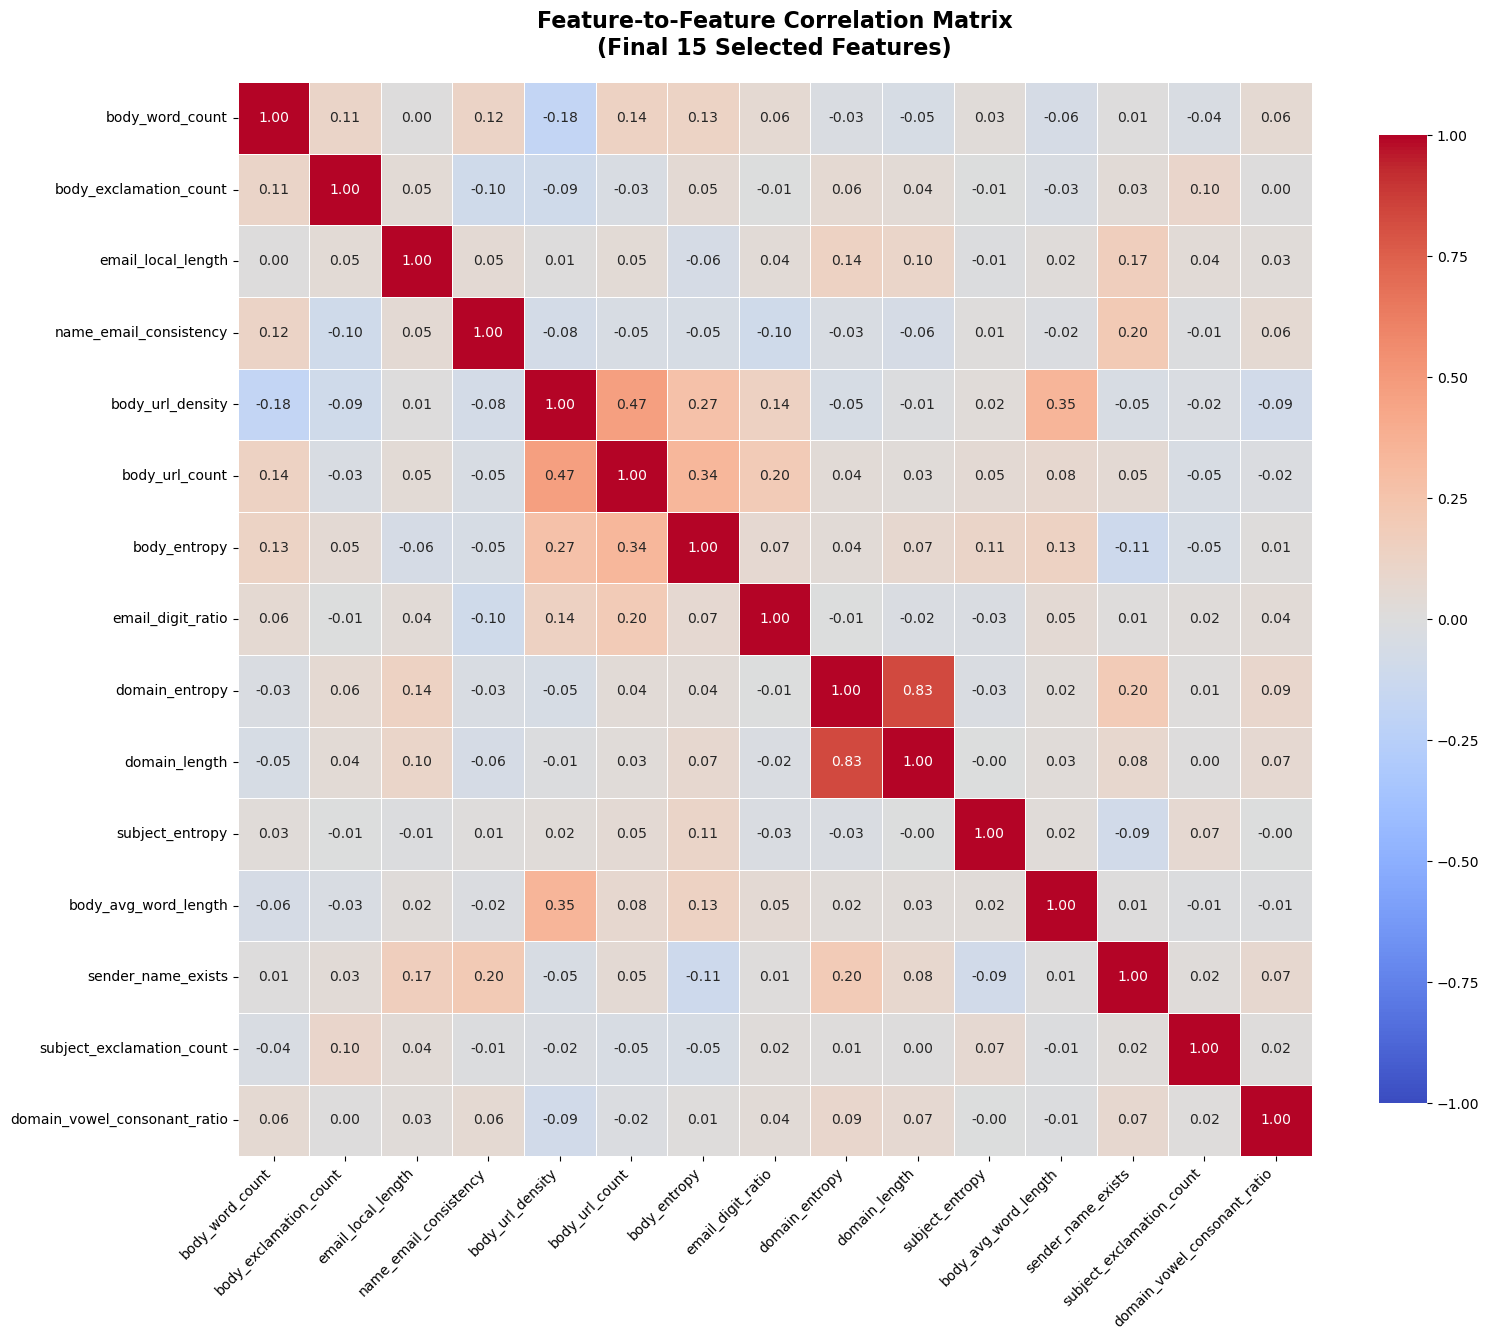

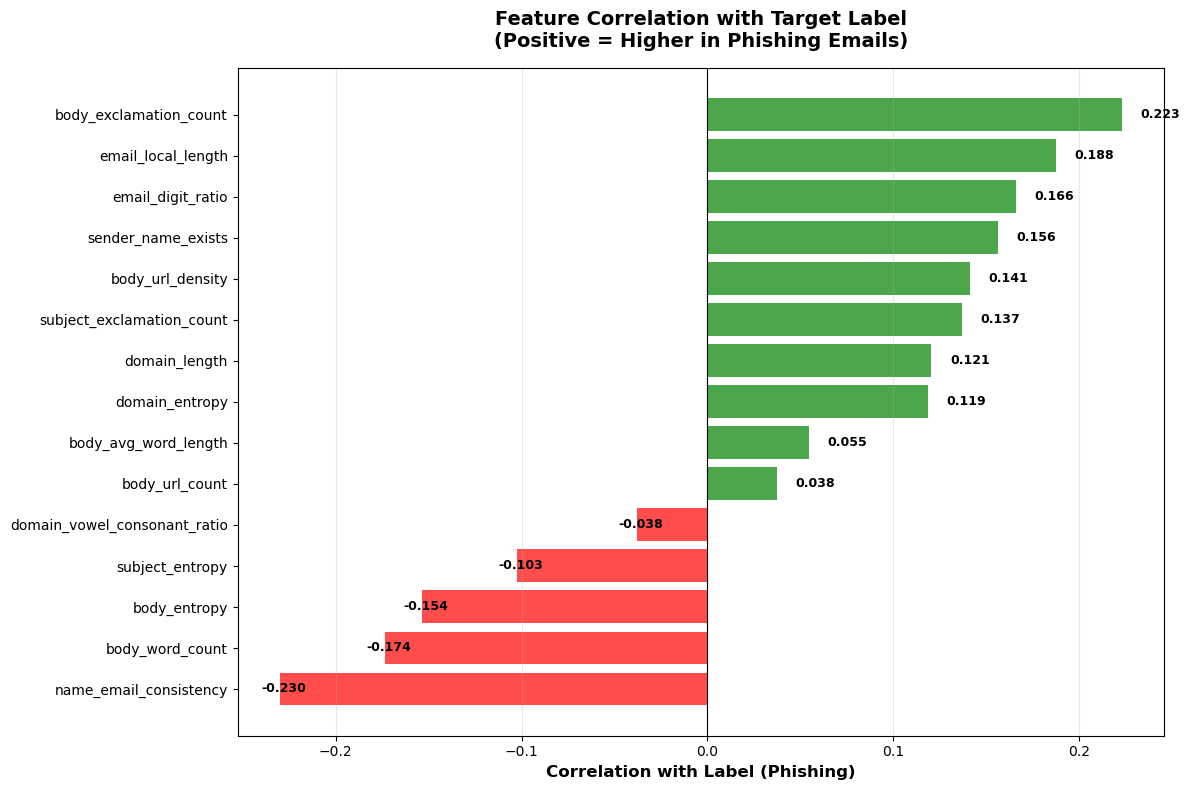

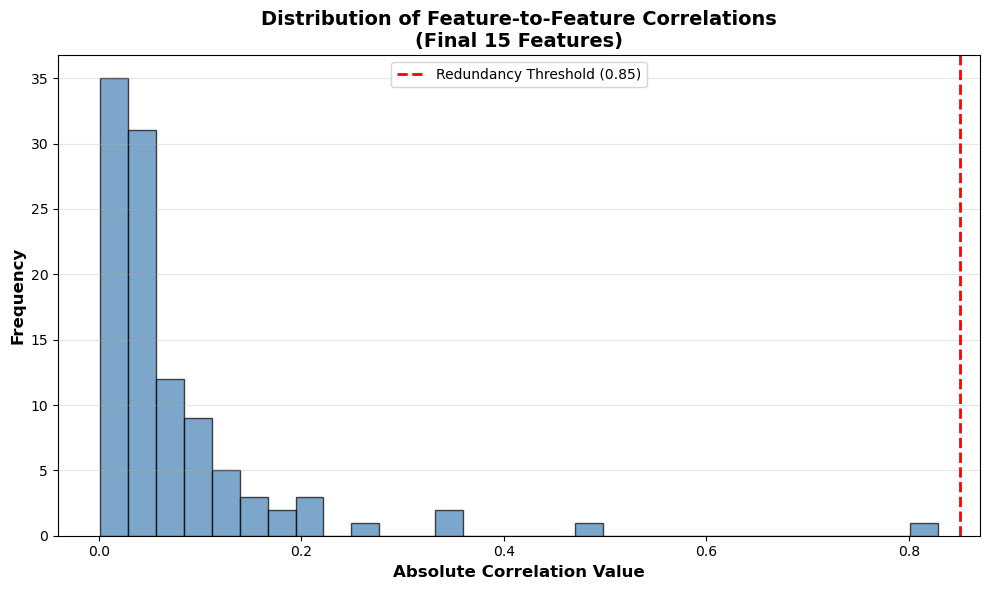

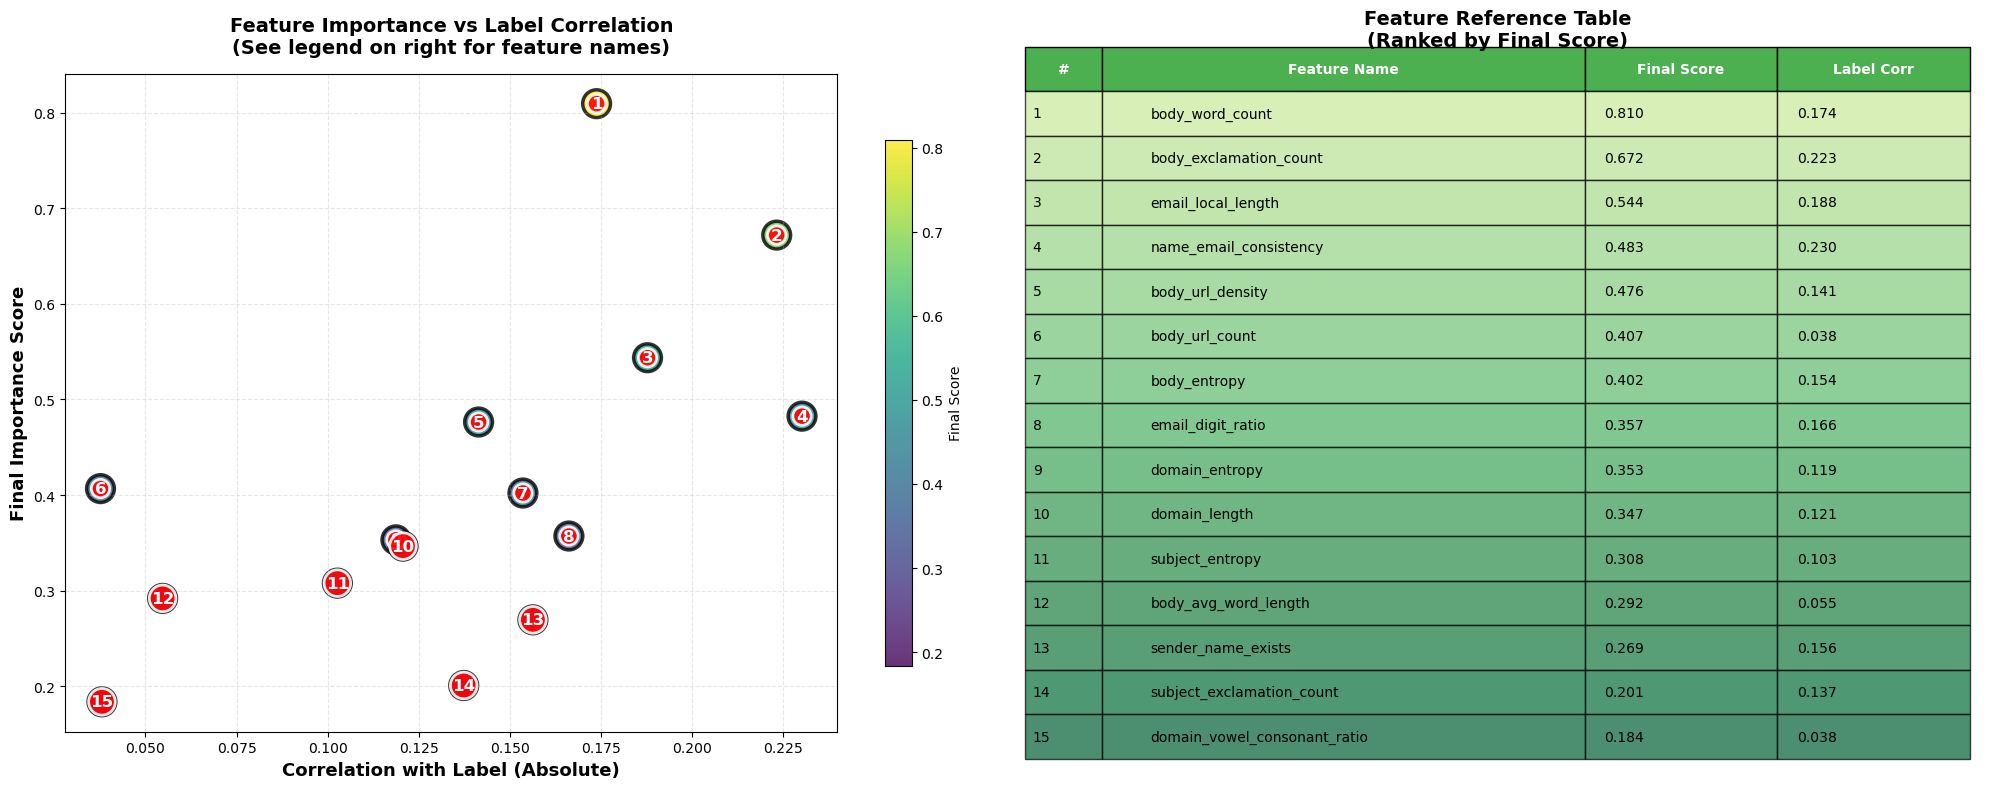

CORRELATION ANALYSIS SUMMARY

Feature-to-Feature Correlations:
  • Maximum correlation: 0.829
  • Average correlation: 0.074
  • Correlations > 0.5: 1
  • Correlations > 0.7: 1
  • Correlations > 0.85: 0 (Should be 0!)

Feature-to-Label Correlations:
  • Strongest positive: body_exclamation_count (0.223)
  • Strongest negative: name_email_consistency (-0.230)
  • Average absolute: 0.136


In [21]:
# Final selected features from Step 5
final_selected_features = ['body_word_count', 'body_exclamation_count', 'email_local_length',
                           'name_email_consistency', 'body_url_density', 'body_url_count', 'body_entropy', 'email_digit_ratio', 'domain_entropy', 'domain_length', 'subject_entropy', 'body_avg_word_length', 'sender_name_exists', 'subject_exclamation_count', 'domain_vowel_consonant_ratio']

print("="*80)
print("STEP 6: CORRELATION VISUALIZATIONS")
print("="*80)
print(f"\nVisualizing {len(final_selected_features)} final selected features\n")

# VISUALIZATION 1: Feature-to-Feature Correlation Heatmap

# Calculate correlation matrix
correlation_matrix = email_df[final_selected_features].corr()

# Create figure
plt.figure(figsize=(16, 14))

# Create heatmap
sns.heatmap(correlation_matrix,
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cmap='coolwarm',  # Color scheme (blue=negative, red=positive)
            center=0,    # Center colormap at 0
            square=True, # Make cells square
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)

plt.title('Feature-to-Feature Correlation Matrix\n(Final 15 Selected Features)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


# VISUALIZATION 2: Feature-to-Label Correlation (Bar Chart)

# Calculate correlation with label
label_correlations = email_df[final_selected_features + ['label']].corr()['label'].drop('label')
label_correlations = label_correlations.sort_values(ascending=True)

# Create figure
plt.figure(figsize=(12, 8))

# Create horizontal bar chart
colors = ['red' if x < 0 else 'green' for x in label_correlations.values]
plt.barh(range(len(label_correlations)), label_correlations.values, color=colors, alpha=0.7)

plt.yticks(range(len(label_correlations)), label_correlations.index, fontsize=10)
plt.xlabel('Correlation with Label (Phishing)', fontsize=12, fontweight='bold')
plt.title('Feature Correlation with Target Label\n(Positive = Higher in Phishing Emails)',
          fontsize=14, fontweight='bold', pad=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(label_correlations.values):
    plt.text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}',
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# VISUALIZATION 3: Correlation Strength Summary
# Get upper triangle of correlation matrix (to avoid duplicates)
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Flatten and remove NaN values
correlations_flat = upper_triangle.stack().abs()

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(correlations_flat, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(x=0.85, color='red', linestyle='--', linewidth=2,
            label='Redundancy Threshold (0.85)')
plt.xlabel('Absolute Correlation Value', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of Feature-to-Feature Correlations\n(Final 15 Features)',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# VISUALIZATION 4: Feature Importance vs Correlation with Label

# Merge final scores with label correlations
viz_data = final_results[final_results['Feature'].isin(final_selected_features)].copy()
viz_data['Label_Correlation'] = viz_data['Feature'].map(
    lambda x: email_df[final_selected_features + ['label']].corr()['label'][x]
).abs()

# Add numbered index for reference
viz_data = viz_data.sort_values('Final_Score', ascending=False).reset_index(drop=True)
viz_data['ID'] = range(1, len(viz_data) + 1)

# Create figure with two subplots side by side
fig = plt.figure(figsize=(20, 8))

# Left subplot: Scatter plot with numbers only
ax1 = plt.subplot(1, 2, 1)

scatter = ax1.scatter(viz_data['Label_Correlation'],
                      viz_data['Final_Score'],
                      s=400,
                      c=viz_data['Final_Score'],
                      cmap='viridis',
                      alpha=0.8,
                      edgecolors='black',
                      linewidths=2.5)

# Add number labels on each point (much cleaner!)
for idx, row in viz_data.iterrows():
    ax1.text(row['Label_Correlation'], row['Final_Score'],
             str(row['ID']),
             fontsize=12,
             fontweight='bold',
             ha='center',
             va='center',
             color='white',
             bbox=dict(boxstyle='circle,pad=0.1',
                      facecolor='red',
                      edgecolor='white',
                      alpha=0.9,
                      linewidth=2))

ax1.set_xlabel('Correlation with Label (Absolute)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Final Importance Score', fontsize=13, fontweight='bold')
ax1.set_title('Feature Importance vs Label Correlation\n(See legend on right for feature names)',
              fontsize=14, fontweight='bold', pad=15)
ax1.grid(alpha=0.3, linestyle='--')
plt.colorbar(scatter, ax=ax1, label='Final Score', shrink=0.8)

# Right subplot: Legend table with feature names
ax2 = plt.subplot(1, 2, 2)
ax2.axis('off')

# Create table data
table_data = []
for idx, row in viz_data.iterrows():
    table_data.append([
        f"{row['ID']}",
        row['Feature'],
        f"{row['Final_Score']:.3f}",
        f"{row['Label_Correlation']:.3f}"
    ])

# Create table
table = ax2.table(cellText=table_data,
                  colLabels=['#', 'Feature Name', 'Final Score', 'Label Corr'],
                  cellLoc='left',
                  loc='center',
                  colWidths=[0.08, 0.50, 0.20, 0.20])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(4):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color rows by importance (gradient)
colors = plt.cm.YlGn(np.linspace(0.3, 0.9, len(viz_data)))
for i in range(len(viz_data)):
    for j in range(4):
        table[(i+1, j)].set_facecolor(colors[i])
        table[(i+1, j)].set_alpha(0.7)

ax2.set_title('Feature Reference Table\n(Ranked by Final Score)',
              fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


# SUMMARY STATISTICS
print("="*80)
print("CORRELATION ANALYSIS SUMMARY")
print("="*80)

print(f"\nFeature-to-Feature Correlations:")
print(f"  • Maximum correlation: {correlations_flat.max():.3f}")
print(f"  • Average correlation: {correlations_flat.mean():.3f}")
print(f"  • Correlations > 0.5: {(correlations_flat > 0.5).sum()}")
print(f"  • Correlations > 0.7: {(correlations_flat > 0.7).sum()}")
print(f"  • Correlations > 0.85: {(correlations_flat > 0.85).sum()} (Should be 0!)")

print(f"\nFeature-to-Label Correlations:")
print(f"  • Strongest positive: {label_correlations.idxmax()} ({label_correlations.max():.3f})")
print(f"  • Strongest negative: {label_correlations.idxmin()} ({label_correlations.min():.3f})")
print(f"  • Average absolute: {label_correlations.abs().mean():.3f}")
print("="*80)

## 3. Combine the selected features and the TF-IDF feature
* Where no longer splitting the data to train and

In [22]:
import pandas as pd

# Selected 15 engineered features
X_engineered = email_df[selected_features]

# All TF-IDF features (7000 columns)
tfidf_cols = [col for col in email_df.columns if 'tfidf' in col]
X_tfidf = email_df[tfidf_cols]

# Combine TF-IDF + Engineered Features + Label
pac_final_data = pd.concat([X_tfidf, X_engineered, email_df[['label']]], axis=1)
pac_final_data

,subject_tfidf_0,subject_tfidf_1,subject_tfidf_2,subject_tfidf_3,subject_tfidf_4,subject_tfidf_5,subject_tfidf_6,subject_tfidf_7,subject_tfidf_8,subject_tfidf_9,subject_tfidf_10,subject_tfidf_11,subject_tfidf_12,subject_tfidf_13,subject_tfidf_14,subject_tfidf_15,subject_tfidf_16,subject_tfidf_17,subject_tfidf_18,subject_tfidf_19,subject_tfidf_20,subject_tfidf_21,subject_tfidf_22,subject_tfidf_23,subject_tfidf_24,subject_tfidf_25,subject_tfidf_26,subject_tfidf_27,subject_tfidf_28,subject_tfidf_29,subject_tfidf_30,subject_tfidf_31,subject_tfidf_32,subject_tfidf_33,subject_tfidf_34,subject_tfidf_35,subject_tfidf_36,subject_tfidf_37,subject_tfidf_38,subject_tfidf_39,subject_tfidf_40,subject_tfidf_41,subject_tfidf_42,subject_tfidf_43,subject_tfidf_44,subject_tfidf_45,subject_tfidf_46,subject_tfidf_47,subject_tfidf_48,subject_tfidf_49,subject_tfidf_50,subject_tfidf_51,subject_tfidf_52,subject_tfidf_53,subject_tfidf_54,subject_tfidf_55,subject_tfidf_56,subject_tfidf_57,subject_tfidf_58,subject_tfidf_59,subject_tfidf_60,subject_tfidf_61,subject_tfidf_62,subject_tfidf_63,subject_tfidf_64,subject_tfidf_65,subject_tfidf_66,subject_tfidf_67,subject_tfidf_68,subject_tfidf_69,subject_tfidf_70,subject_tfidf_71,subject_tfidf_72,subject_tfidf_73,subject_tfidf_74,subject_tfidf_75,subject_tfidf_76,subject_tfidf_77,subject_tfidf_78,subject_tfidf_79,subject_tfidf_80,subject_tfidf_81,subject_tfidf_82,subject_tfidf_83,subject_tfidf_84,subject_tfidf_85,subject_tfidf_86,subject_tfidf_87,subject_tfidf_88,subject_tfidf_89,subject_tfidf_90,subject_tfidf_91,subject_tfidf_92,subject_tfidf_93,subject_tfidf_94,subject_tfidf_95,subject_tfidf_96,subject_tfidf_97,subject_tfidf_98,subject_tfidf_99,subject_tfidf_100,subject_tfidf_101,subject_tfidf_102,subject_tfidf_103,subject_tfidf_104,subject_tfidf_105,subject_tfidf_106,subject_tfidf_107,subject_tfidf_108,subject_tfidf_109,subject_tfidf_110,subject_tfidf_111,subject_tfidf_112,subject_tfidf_113,subject_tfidf_114,subject_tfidf_115,subject_tfidf_116,subject_tfidf_117,subject_tfidf_118,subject_tfidf_119,subject_tfidf_120,subject_tfidf_121,subject_tfidf_122,subject_tfidf_123,subject_tfidf_124,subject_tfidf_125,subject_tfidf_126,subject_tfidf_127,subject_tfidf_128,subject_tfidf_129,subject_tfidf_130,subject_tfidf_131,subject_tfidf_132,subject_tfidf_133,subject_tfidf_134,subject_tfidf_135,subject_tfidf_136,subject_tfidf_137,subject_tfidf_138,subject_tfidf_139,subject_tfidf_140,subject_tfidf_141,subject_tfidf_142,subject_tfidf_143,subject_tfidf_144,subject_tfidf_145,subject_tfidf_146,subject_tfidf_147,subject_tfidf_148,subject_tfidf_149,subject_tfidf_150,subject_tfidf_151,subject_tfidf_152,subject_tfidf_153,subject_tfidf_154,subject_tfidf_155,subject_tfidf_156,subject_tfidf_157,subject_tfidf_158,subject_tfidf_159,subject_tfidf_160,subject_tfidf_161,subject_tfidf_162,subject_tfidf_163,subject_tfidf_164,subject_tfidf_165,subject_tfidf_166,subject_tfidf_167,subject_tfidf_168,subject_tfidf_169,subject_tfidf_170,subject_tfidf_171,subject_tfidf_172,subject_tfidf_173,subject_tfidf_174,subject_tfidf_175,subject_tfidf_176,subject_tfidf_177,subject_tfidf_178,subject_tfidf_179,subject_tfidf_180,subject_tfidf_181,subject_tfidf_182,subject_tfidf_183,subject_tfidf_184,subject_tfidf_185,subject_tfidf_186,subject_tfidf_187,subject_tfidf_188,subject_tfidf_189,subject_tfidf_190,subject_tfidf_191,subject_tfidf_192,subject_tfidf_193,subject_tfidf_194,subject_tfidf_195,subject_tfidf_196,subject_tfidf_197,subject_tfidf_198,subject_tfidf_199,subject_tfidf_200,subject_tfidf_201,subject_tfidf_202,subject_tfidf_203,subject_tfidf_204,subject_tfidf_205,subject_tfidf_206,subject_tfidf_207,subject_tfidf_208,subject_tfidf_209,subject_tfidf_210,subject_tfidf_211,subject_tfidf_212,subject_tfidf_213,subject_tfidf_214,subject_tfidf_215,subject_tfidf_216,subject_tfidf_217,subject_tfidf_218,subject_tfidf_219,subject_tfidf_220,subject_tfidf_221,subject_tfidf_222,subject_tfidf_223,subject_tfidf_224,subject_tfidf_225,subject_tfidf_226,subject_tfidf_227,subje

In [23]:
# Export Training Data to CSV
import os
# Create directory
os.makedirs('datasets/training', exist_ok=True)

# Export
output_path = 'datasets/training/final_dataset.csv'
pac_final_data.to_csv(output_path, index=False)

print(f"\nDataset exported to: {output_path}")
print(f"Shape: {pac_final_data.shape}")
print(f"Total columns: {pac_final_data.shape[1]} (7015 features + 1 label)")


Dataset exported to: datasets/training/final_dataset.csv
Shape: (99115, 7016)
Total columns: 7016 (7015 features + 1 label)
